<a href="https://colab.research.google.com/github/pop123-ux/HuggingFace-Project-Learning/blob/main/course/chapter6/Normalization_and_Pre-tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Normalization and pre-tokenization

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [1]:
!pip install datasets evaluate transformers[sentencepiece]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(type(tokenizer.backend_tokenizer))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

<class 'tokenizers.Tokenizer'>


In [ ]:
tokenizer.backend_tokenizer.normalizer.normalize_str("Héllò hôw are ü?")

'hello how are u?'

In [3]:
tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str('Hello, how are you?')

[('Hello', (0, 5)),
 (',', (5, 6)),
 ('how', (7, 10)),
 ('are', (11, 14)),
 ('you', (15, 18)),
 ('?', (18, 19))]

In [4]:
 tokenizer = AutoTokenizer.from_pretrained('gpt2')
 tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str("Hello, how are you?")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[('Hello', (0, 5)),
 (',', (5, 6)),
 ('Ġhow', (6, 10)),
 ('Ġare', (10, 14)),
 ('Ġyou', (14, 18)),
 ('?', (18, 19))]

It split on whitespace and punctuation as well, but it will keep the spaces and replace it with  a Ġ symbol, enabling it to recover the original spaces if we decode the tokens

Let's look at the T5 tokenizer, which it based on the SentencePiece algorithm:

In [6]:
tokenizer = AutoTokenizer.from_pretrained('t5-small')
tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str("Hello, how are  you?")

[('▁Hello,', (0, 6)),
 ('▁how', (7, 10)),
 ('▁are', (11, 14)),
 ('▁you?', (16, 20))]

Like the GPT-2 tokenizer, this one keeps spaces and replaces them with a specific token (_), but the T5 tokenizer only splits on whitespace, not punctuation

We also note that it added a space by default at the beginning of the sentence (before Hello) and ignored the double space between are and you.

## SentencePiece ##

SentencePiece is a tokenization algorithm for the preprocessing of text that you can use with any of the models we will see in the next three sections. It considers the text as a sequence of Unicode characters, and replaces spaces with a special character, ▁.

Used in conjunction with the Unigram algorithm, it doesn’t even require a pre-tokenization step, which is very useful for languages where the space character is not used (like Chinese or Japanese).

The other main feature of SentencePiece is reversible tokenization: since there is no special treatment of spaces, decoding the tokens is done simply by concatenating them and replacing the _s with spaces — this results in the normalized text.


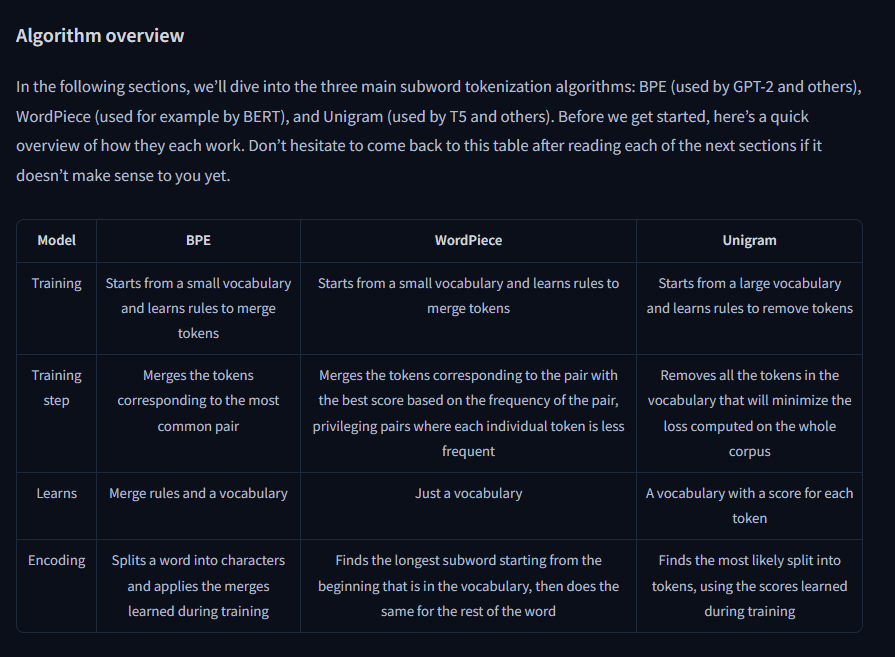